#

# Лабораторная работа 4. Кластеризация

## Описание работы
**Цель работы:** изучение алгоритмов кластеризации, приобретение навыков оценки качества разбиения данных на кластеры и интерпретации результатов.

**Постановка задачи:**

1. Загрузить датасет для задачи кластеризации / классификации (например, с платформы Kaggle). Провести дескриптивный анализ данных: определить размерность, типы признаков, наличие пропусков. Оценить распределение переменных (близость к нормальному) с использованием визуализации (гистограммы). Проверить условие применения кластеризации: отсутствие классов, осмысленность кластеризации, отсутствие выбросов.

1. Выполнить стандартизацию / нормализацию числовых признаков. Обосновать выбор метода масштабирования. Построить матрицу диаграмм рассеивания для визуальной оценки структуры данных, предположительного количества кластеров и типа кластерной структуры. Аргументировать выбор методов кластеризации на основе формы, размера и плотности кластеров.

1. Реализовать кластеризацию двумя различными методами на выбор: K-means (K-средних); иерархическая кластеризация; DBSCAN; EM-алгоритм (Gaussian Mixture). Для методов, требующих задания числа кластеров (K-means, иерархическая), подобрать оптимальное значение k с использованием: метода локтя и / или анализа силуэта.

1. Рассчитать метрики качества для обоих методов: внутренние и внешние. Оценить расстояние между кластерами, внутрикластерные расстояния, компактность кластеров, центры кластеров. Опционально, если известно разделение на классы, посчитать: индекс Rand, индекс Жаккара и др. внешние метрики. Привести содержательную интерпретацию полученных значений.

1. Исследовать влияние параметров одного из методов (например, ε и min_samples для DBSCAN или количества кластеров k для K-means) на качество кластеризации.

1. Визуализировать полученные кластеры в пространстве признаков (использовать PCA для снижения размерности при необходимости). Проанализировать центры кластеров (для K-means) и дать содержательную интерпретацию выделенных групп. Сравнить результаты, полученные двумя разными методами.

## Ход работы

**О датасете:** Датасет содержит наблюдений объектов (рыб) различных видов и 3 количественных признака: длина (length), масса (weight) и соотношение массы к длине (w_l_ratio). Первоначально в наборе данных также присутствовал признак species, указывающий на вид рыбы, который использовался только для оценки качества кластеризации, но не участвовал в самом процессе кластеризации.

Признаки:

1. Длина рыбы (length) — измеряется в сантиметрах. Значения колеблются от примерно 5 см до 35 см. Этот признак позволяет различать рыбу по размеру и является одним из ключевых факторов для кластеризации.

1. Масса рыбы (weight) — измеряется в килограммах.

1. Соотношение массы к длине (w_l_ratio) — безразмерный показатель, показывающий “плотность” или упитанность рыбы. Он помогает отделять рыбу одного размера, но различной комплекции.

### Анализ данных

Сначала датасет и выведем первые пять строк.


In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv('datasets/fish_data.csv')
data



,species,length,weight,w_l_ratio
0,Anabas testudineus,10.66,3.45,0.32
1,Anabas testudineus,6.91,3.27,0.47
2,Anabas testudineus,8.38,3.46,0.41
3,Anabas testudineus,7.57,3.36,0.44
4,Anabas testudineus,10.83,3.38,0.31
...,...,...,...,...
4075,Sillaginopsis panijus,30.56,6.12,0.20
4076,Sillaginopsis panijus,29.66,6.11,0.21
4077,Sillaginopsis panijus,32.81,6.25,0.19
4078,Sillaginopsis panijus,29.78,6.11,0.21


Удалилим класс рыб для того, чтобы использовать кластеризацию, но также сохраним классы для подсчета внешних метрик

In [115]:
from sklearn.preprocessing import LabelEncoder

y_true = data['species']

le = LabelEncoder()

y_true = le.fit_transform(y_true)

data.drop(columns='species', axis=1, inplace=True)


Далее узнаем тип признаков

In [116]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   length     4080 non-null   float64
 1   weight     4080 non-null   float64
 2   w_l_ratio  4080 non-null   float64
dtypes: float64(3)
memory usage: 95.8 KB


Как видим будем работать только с вещественными переменнами

Также проверим на наличие пропусков:

In [117]:
data.isna().sum()

length       0
weight       0
w_l_ratio    0
dtype: int64

Пропуски отсутствуют, поэтому дополнительная очистка данных по этому признаку не требовалась. Все записи корректны и могут быть использованы для анализа и кластеризации, что обеспечивает полноту и достоверность дальнейших вычислений.

Далее выведем основные статистические характеристики каждого числового признака после удаления признака species и очистки данных.

In [118]:
data.describe().round(2)

,length,weight,w_l_ratio
count,4080.00,4080.00,4080.00
mean,17.35,3.74,0.25
std,7.11,1.04,0.12
min,6.36,2.05,0.08
25%,11.33,3.07,0.17
50%,17.35,3.31,0.19
75%,22.58,4.10,0.34
max,33.86,6.29,0.64


Датасет демонстрирует значительное разнообразие рыб по длине и массе, при этом длина варьируется от 6.36 до 33.86 см со средним значением 17.35 см, а масса — от 2.05 до 6.29 кг со средним 3.74 кг, что отражает широкий разброс биологических характеристик; показатель w_l_ratio, отражающий соотношение массы к длине, имеет меньший диапазон (0.08–0.64) и среднее 0.25, показывая различия в упитанности рыб; такое распределение признаков требует их масштабирования перед применением алгоритмов кластеризации для корректного расчёта расстояний между объектами.

Постоим гистограммы для того, чтобы  узнать как распределены основные количественные признаки датасета.

array([[<Axes: title={'center': 'length'}>,
        <Axes: title={'center': 'weight'}>],
       [<Axes: title={'center': 'w_l_ratio'}>, <Axes: >]], dtype=object)

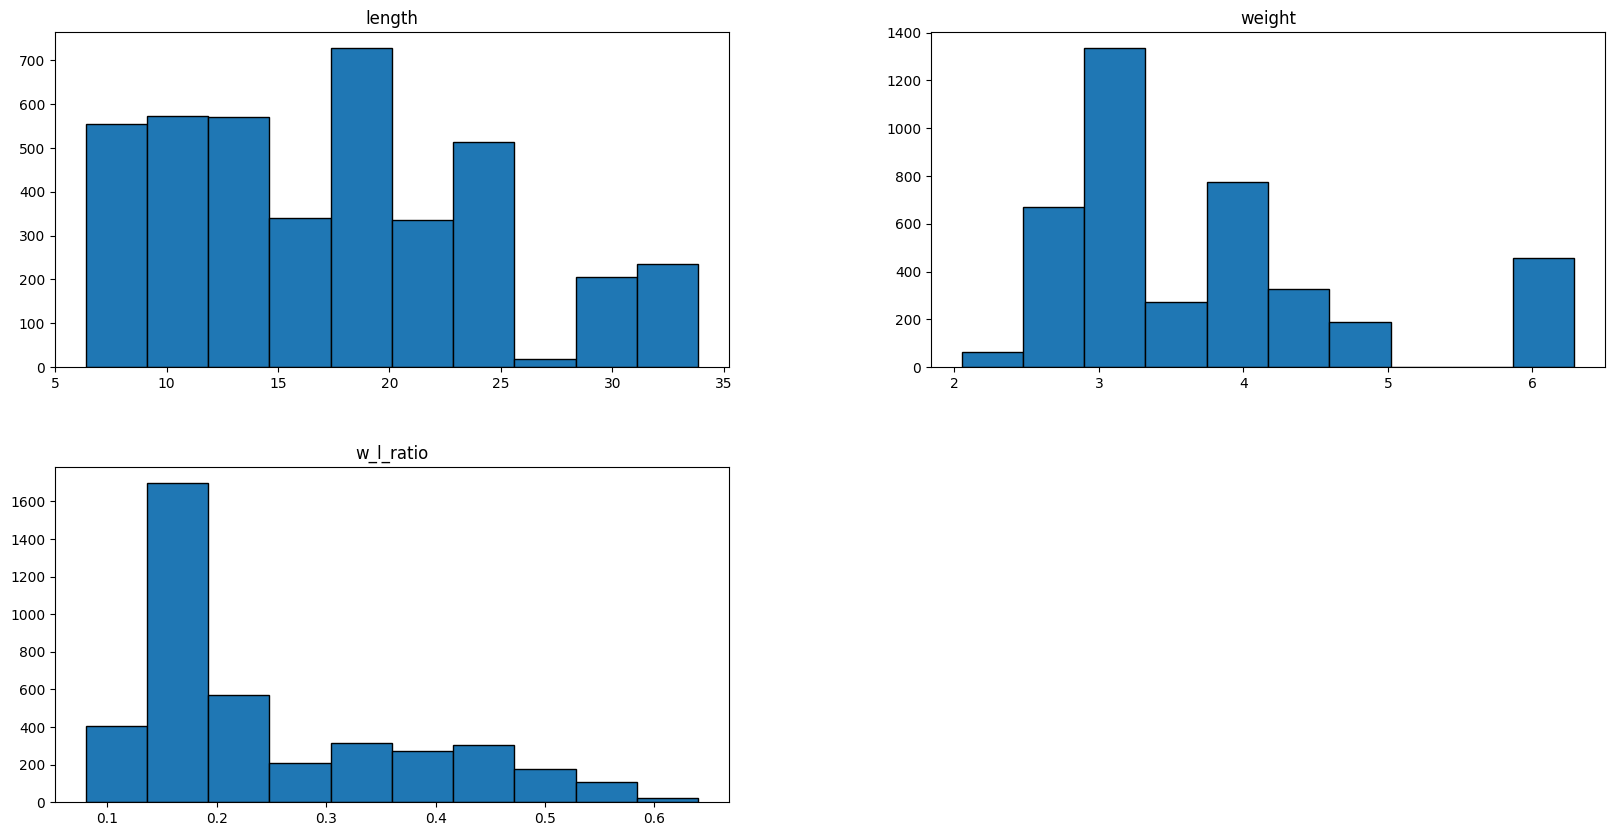

In [119]:
data.hist(figsize=(20,10), grid=False, edgecolor='black')

### Нормализация

После очистки данных и анализа статистических характеристик была проведена нормализация признаков с помощью метода MinMaxScaler

Выбор MinMaxScaler обоснован тем, что признаки датасета имеют разные диапазоны, и алгоритмы кластеризации, чувствительные к расстояниям, требуют одинакового масштаба для корректной работы. Кроме того, MinMaxScaler сохраняет относительные различия между значениями и приводит их к диапазону [0, 1], что упрощает интерпретацию и визуализацию данных.

In [120]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(data)     # numpy
scaler_data = pd.DataFrame(X_scaled, columns=data.columns)
scaler_data

,length,weight,w_l_ratio
0,0.156364,0.330189,0.428571
1,0.020000,0.287736,0.696429
2,0.073455,0.332547,0.589286
3,0.044000,0.308962,0.642857
4,0.162545,0.313679,0.410714
...,...,...,...
4075,0.880000,0.959906,0.214286
4076,0.847273,0.957547,0.232143
4077,0.961818,0.990566,0.196429
4078,0.851636,0.957547,0.232143


#### Диаграмма рассеивания
Для визуальной оценки структуры данных была построена матрица диаграмм рассеяния

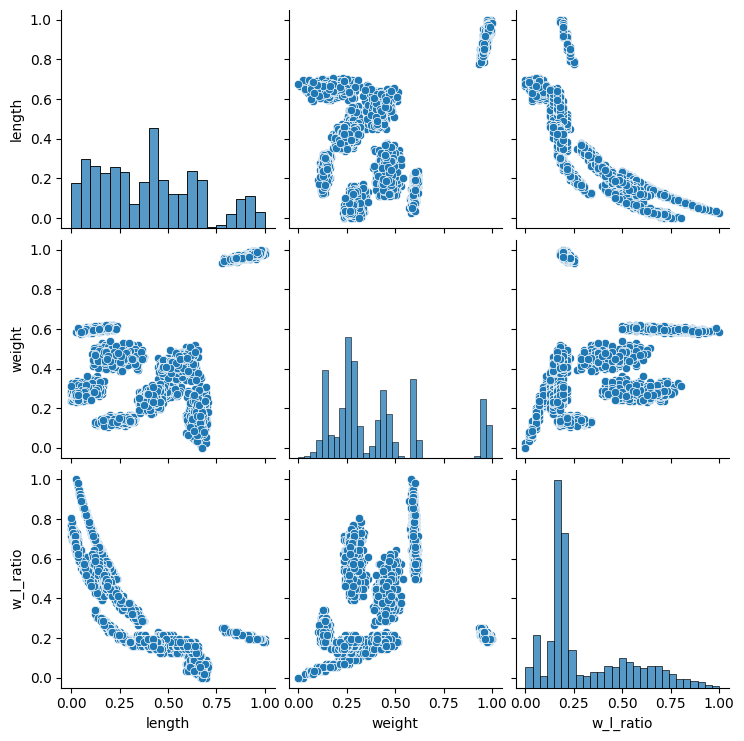

In [121]:
sns.pairplot(scaler_data)



Анализ матрицы диаграмм рассеяния показал наличие нескольких компактных групп объектов, что позволяет предположить 8 кластеров. Кластеры имеют ленточную форму, для такой формы подойдут такие методы как иерархическая кластеризация и DBSCAN.


### DBSCAN

Для метода DBSCAN оптимальные параметры — это eps (максимальное расстояние между соседними точками) и min_samples (минимальное количество точек, формирующих плотный кластер).

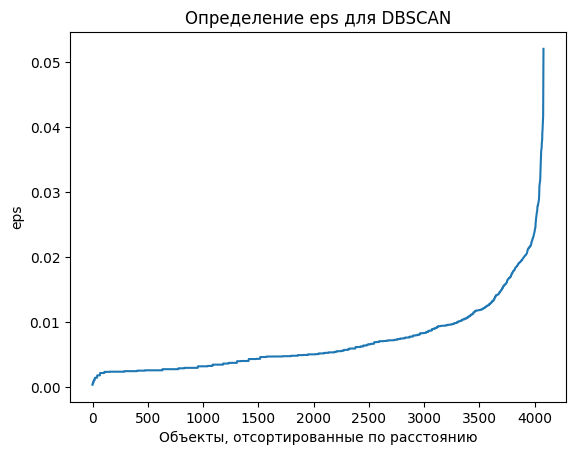

In [122]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances, axis=0)  # расстояние до 5-го соседа
plt.plot(distances[:,4])
plt.ylabel("eps")
plt.xlabel("Объекты, отсортированные по расстоянию")
plt.title("Определение eps для DBSCAN")
plt.show()


На графике ищут точку «излома», после которой расстояния резко возрастают, и выбирают её значение в качестве eps. Это позволяет алгоритму корректно выделять плотные кластеры и отделять шумовые точки.
Для нашего примера это точка в диапозоне от 0.01 до 0.03

Построим модель с eps = 0.03 и min_samples = 5 

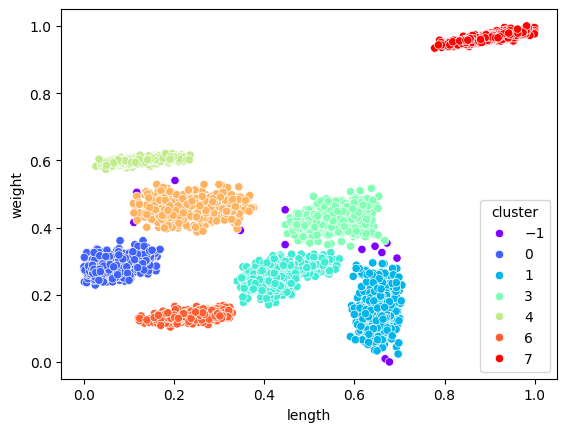

In [123]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.03, min_samples=5)

y_dbscan = dbscan.fit_predict(X_scaled)

scaler_data['cluster'] = dbscan.labels_

sns.scatterplot(x = scaler_data['length'], y=scaler_data['weight'], hue=scaler_data['cluster'], palette="rainbow")

scaler_data['cluster'].value_counts()
scaler_data.drop(columns='cluster', axis=1, inplace=True)

Кластеры с номером -1 DBSCAN определил как шум

### Иерархическая кластеризация

Для выбора оптимального числа кластеров k в иерархической кластеризации можно использовать силуэт-оценку или визуальный анализ дендрограммы.

#### Дендрограмма

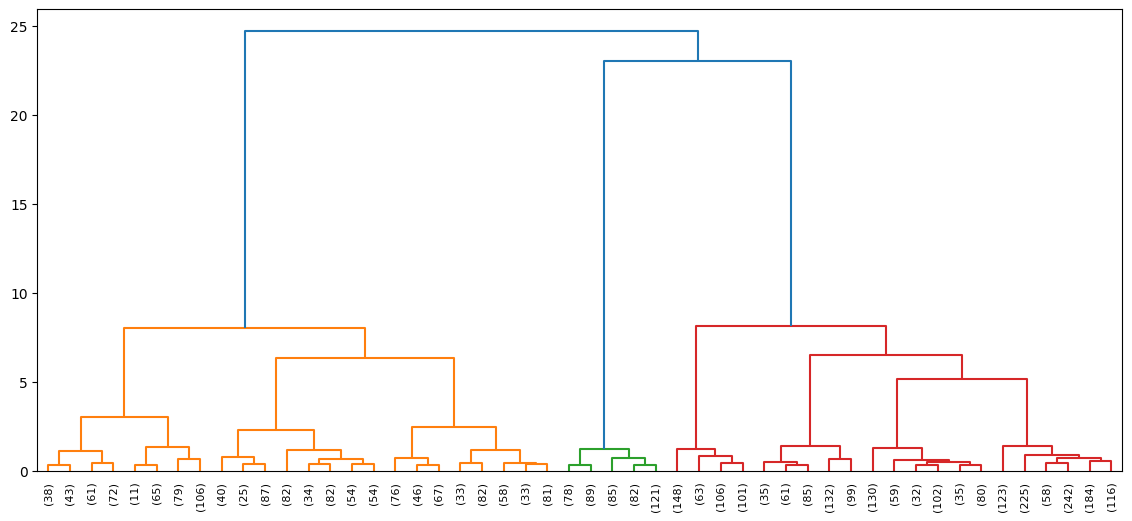

In [124]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(14, 6))
dendrogram(
    linkage(X_scaled, method='ward'),
    truncate_mode='lastp',
    p=50,
)
plt.show()

На дендограмме можно выделить 8 кластеров

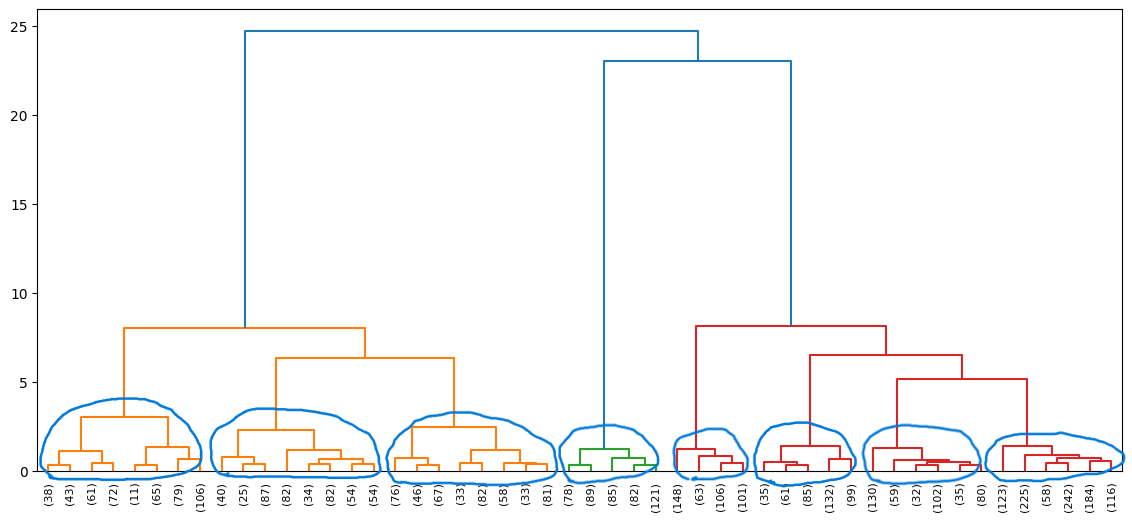

#### Силуэт



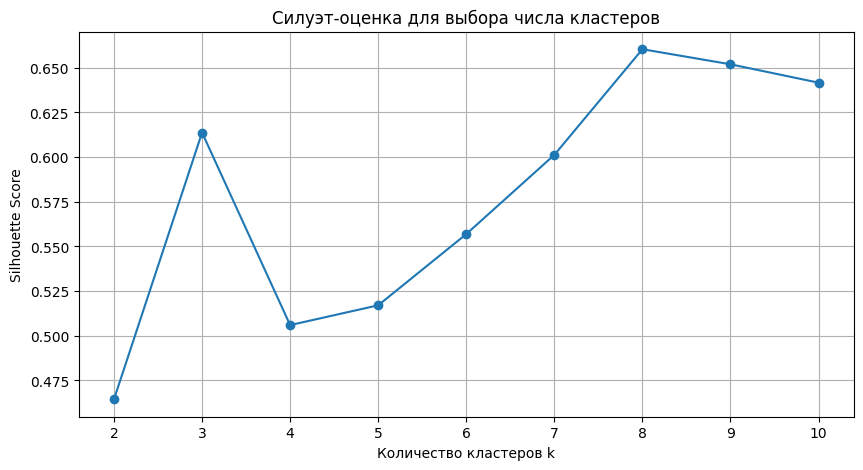

In [125]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

K_range = range(2, 11) 
silhouette = []

for k in K_range:
    ac = AgglomerativeClustering(n_clusters=k)
    labels = ac.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette.append(score)

plt.figure(figsize=(10,5))
plt.plot(K_range, silhouette, marker='o')
plt.title("Силуэт-оценка для выбора числа кластеров")
plt.xlabel("Количество кластеров k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()



Значение силуэта достигает максимума 0.66 при k=8, что указывает на наилучшую разделимость кластеров и высокую компактность объектов внутри них. Для меньшего числа кластеров (k=2–7) силуэт ниже, что свидетельствует о слиянии различных групп в слишком крупные кластеры. Для большего числа кластеров (k=9–10) значение силуэта слегка снижается, что отражает избыточное дробление естественных групп. Таким образом, оптимальным числом кластеров для иерархической кластеризации на данном датасете является 8.

Постоим модель с k=8

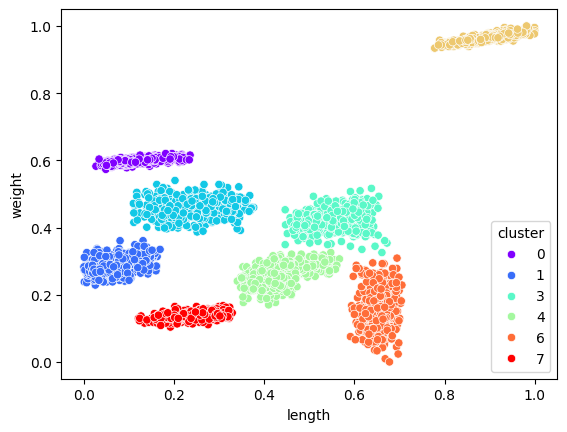

In [126]:

model_ac = AgglomerativeClustering(
    n_clusters=8,
    linkage='ward'
)


y_ac = model_ac.fit_predict(X_scaled)

scaler_data['cluster'] = model_ac.labels_

sns.scatterplot(x = scaler_data['length'], 
                y = scaler_data['weight'], 
                hue = scaler_data['cluster'], 
                palette="rainbow")

plt.show()
scaler_data['cluster'].value_counts()
scaler_data.drop(columns='cluster', axis=1, inplace=True)

### Расчет метрик качества

#### Внутренние метрики

Внутренние метрики отображают качество кластеризации только по информации в данных.

##### Компактность кластеров (Cluster Cohesion)
Идея данного метода в том, что чем ближе друг к другу находятся объекты внутри кластеров, тем лучше разделение.

Таким образом, необходимо минимизировать внутриклассовое расстояние, например, сумму квадратов отклонений:

In [127]:

def cluster_cohesion(X, labels):
    
    X = np.array(X)
    labels = np.array(labels)

    clusters = np.unique(labels)

    
    WSS = 0.0
    per_cluster_wss = {}
    for cluster in clusters:
        if (cluster == -1):
            continue
        points = X[labels == cluster]
        mean_cluster = points.mean(axis=0)
        wss = np.sum(np.linalg.norm(points - mean_cluster, axis=1)**2)
        per_cluster_wss[cluster] = float(wss)
        WSS += wss
    
    return float(WSS)



Посчитаем данную метрику для наших методов

In [ ]:
wss_dbscan = cluster_cohesion(X_scaled, y_dbscan)

wss_ac =cluster_cohesion(X_scaled, y_ac)

print(wss_dbscan)

print(wss_ac)

24.453885186008037
24.81169411467676


##### Отделимость кластеров (Cluster Separation)

В данном случае идея противоположная — чем дальше друг от друга находятся объекты разных кластеров, тем лучше.

Поэтому здесь стоит задача максимизации суммы квадратов отклонений:

In [ ]:
def cluster_separation(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    global_mean = X.mean(axis=0)

    clusters = np.unique(labels)

    BSS = 0.0
    per_cluster_bss = {}

    for cluster in clusters:
        if (cluster == -1):
            continue
        points = X[labels == cluster]
        mean_cluster = points.mean(axis=0)

        bss_j = np.linalg.norm(mean_cluster - global_mean)**2
        per_cluster_bss[cluster] = float(bss_j)

        BSS += bss_j

    BSS_total = n * BSS

    return float(BSS_total)

Посчитаем данную метрику для наших методов

In [141]:
bss_dbscan = cluster_separation(X_scaled, y_dbscan)

bss_ac =cluster_separation(X_scaled, y_ac)

print(bss_dbscan)

print(bss_ac)

6105.998401404039
6035.60781970059


##### Силуэт (Silhouette)

Значение силуэта показывает, насколько объект похож на свой кластер по сравнению с другими кластерами.

Чем ближе данная оценка к 1, тем лучше.

Посчитаем данную метрику для наших методов

In [135]:
from sklearn.metrics import silhouette_score

dbscan_silhouette_score = silhouette_score(X_scaled, y_dbscan)

ac_silhouette_score = silhouette_score(scaler_data, y_ac)

print(dbscan_silhouette_score)

print(ac_silhouette_score)

0.6589219263276387
0.6603614128742454


#### Внешние метрики

Внешние меры основаны на сравнении результата кластеризации с априори известным разделением на классы.

У нас есть заранее известные классы в y_true (9 кластеров)

In [130]:
from sklearn.metrics import adjusted_rand_score, pair_confusion_matrix, rand_score

adjusted_rand_score(y_true, y_ac)

adjusted_rand_score(y_true, y_dbscan)

(tn, fp), (fn, tp) = pair_confusion_matrix(y_true, y_dbscan)

rand_score(y_true, y_dbscan)

pair_confusion_matrix(y_true, y_dbscan)

array([[14341558,   450254],
       [   11998,  1838510]])